# Timing

This notebook gives a rough estimate of IXPLORE's runtime and how it scales.

- Time a single iteration on demo-sized data, broken down by step.
- Sweep `n_users` and `n_items` to show scaling behavior.
- Sweep `sampling_resolution` (the grid size).

In [1]:
import time
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ixplore import IXPLORE

logging.getLogger('ixplore').setLevel(logging.WARNING)

## Helpers

A small helper that builds a random reaction matrix of a given size, and another that times one iteration step by step.

In [2]:
def make_reactions(n_users, n_items, seed=0):
    rng = np.random.default_rng(seed)
    data = rng.random((n_users, n_items))
    return pd.DataFrame(data,
                        index=[f'user{i}' for i in range(n_users)],
                        columns=[f'Q{j+1}' for j in range(n_items)])


def time_iteration(model, n_runs=3):
    steps = ['fit_posteriors', 'fit_models', 'evaluate']
    timings = {s: [] for s in steps}
    for _ in range(n_runs):
        t0 = time.perf_counter(); model.fit_posteriors()
        t1 = time.perf_counter(); model.fit_models()
        t2 = time.perf_counter(); model.evaluate()
        t3 = time.perf_counter()
        timings['fit_posteriors'].append(t1 - t0)
        timings['fit_models'].append(t2 - t1)
        timings['evaluate'].append(t3 - t2)
    return {k: float(np.mean(v)) for k, v in timings.items()}

## Per-iteration breakdown

We time each step of one iteration on demo-sized data (500 users × 100 items, default grid).

In [3]:
reactions = make_reactions(500, 100)
model = IXPLORE(reactions)

timings = time_iteration(model)
total = sum(timings.values())

breakdown = pd.DataFrame({
    'time (s)': list(timings.values()),
    '% of total': [100 * t / total for t in timings.values()],
}, index=list(timings.keys()))
breakdown.loc['total'] = [total, 100.0]
breakdown.round(4)

,time (s),% of total
fit_posteriors,0.2163,59.5819
fit_models,0.1459,40.1724
evaluate,0.0009,0.2458
total,0.3631,100.0000


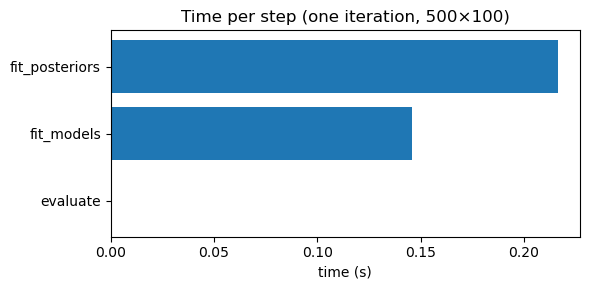

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(list(timings.keys()), list(timings.values()), color='C0')
ax.set_xlabel('time (s)')
ax.set_title('Time per step (one iteration, 500×100)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Scaling with `n_users`

Number of items fixed at 100; we vary the number of users.

In [5]:
user_counts = [50, 100, 250, 500, 1000, 2500, 5000]
rows = []
for n in user_counts:
    m = IXPLORE(make_reactions(n, 100))
    t = time_iteration(m, n_runs=2)
    t['n_users'] = n
    t['total'] = sum(v for k, v in t.items() if k != 'n_users')
    rows.append(t)

df_users = pd.DataFrame(rows).set_index('n_users')
df_users.round(3)

,fit_posteriors,fit_models,evaluate,total
n_users,,,,
50,0.025,0.130,0.000,0.155
100,0.038,0.130,0.000,0.169
250,0.102,0.137,0.001,0.239
500,0.175,0.144,0.001,0.320
1000,0.395,0.162,0.002,0.559
2500,1.094,0.212,0.005,1.311
5000,2.403,0.303,0.009,2.714


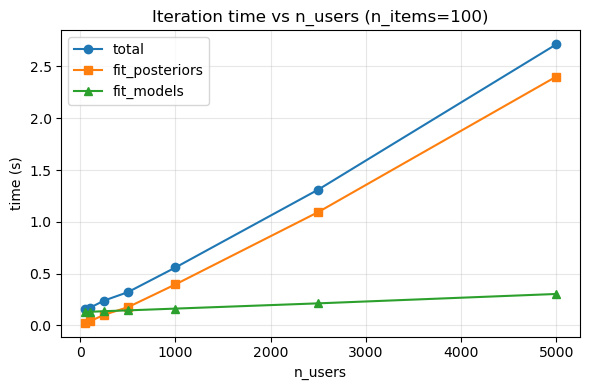

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_users.index, df_users['total'], 'o-', label='total')
ax.plot(df_users.index, df_users['fit_posteriors'], 's-', label='fit_posteriors')
ax.plot(df_users.index, df_users['fit_models'], '^-', label='fit_models')
ax.set_xlabel('n_users')
ax.set_ylabel('time (s)')
ax.set_title('Iteration time vs n_users (n_items=100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Scaling with `n_items`

Number of users fixed at 500; we vary the number of items.

In [7]:
item_counts = [10, 25, 50, 100, 200, 500]
rows = []
for k in item_counts:
    m = IXPLORE(make_reactions(500, k))
    t = time_iteration(m, n_runs=2)
    t['n_items'] = k
    t['total'] = sum(v for kk, v in t.items() if kk != 'n_items')
    rows.append(t)

df_items = pd.DataFrame(rows).set_index('n_items')
df_items.round(3)

,fit_posteriors,fit_models,evaluate,total
n_items,,,,
10,0.178,0.016,0.000,0.194
25,0.160,0.038,0.000,0.198
50,0.183,0.074,0.001,0.258
100,0.178,0.148,0.001,0.328
200,0.202,0.293,0.002,0.498
500,0.242,0.754,0.005,1.001


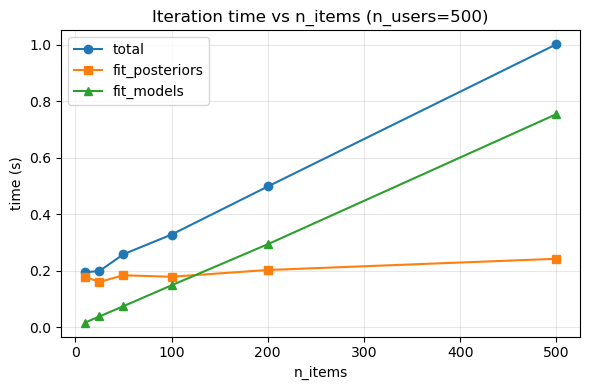

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_items.index, df_items['total'], 'o-', label='total')
ax.plot(df_items.index, df_items['fit_posteriors'], 's-', label='fit_posteriors')
ax.plot(df_items.index, df_items['fit_models'], '^-', label='fit_models')
ax.set_xlabel('n_items')
ax.set_ylabel('time (s)')
ax.set_title('Iteration time vs n_items (n_users=500)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Scaling with `sampling_resolution`

The posterior is computed over a `sampling_resolution × sampling_resolution` grid. We vary the resolution at fixed data size (250 × 70).

In [9]:
resolutions = [50, 75, 100, 150, 200]
rows = []
for res in resolutions:
    m = IXPLORE(make_reactions(250, 70), sampling_resolution=res)
    t = time_iteration(m, n_runs=2)
    t['resolution'] = res
    t['grid_points'] = res * res
    t['total'] = sum(v for k, v in t.items() if k not in ('resolution', 'grid_points'))
    rows.append(t)

df_res = pd.DataFrame(rows).set_index('resolution')
df_res.round(3)

,fit_posteriors,fit_models,evaluate,grid_points,total
resolution,,,,,
50,0.009,0.022,0.000,2500,0.031
75,0.018,0.029,0.000,5625,0.048
100,0.024,0.038,0.000,10000,0.063
150,0.051,0.063,0.000,22500,0.114
200,0.088,0.097,0.001,40000,0.185


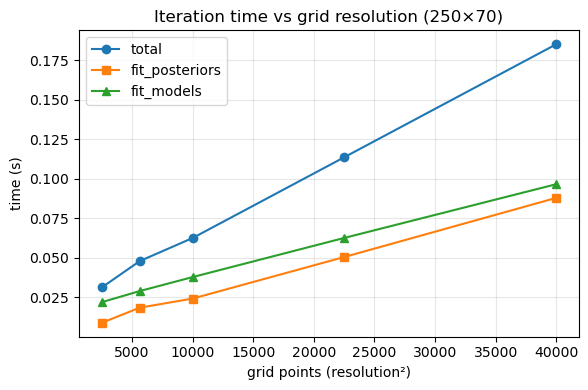

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_res['grid_points'], df_res['total'], 'o-', label='total')
ax.plot(df_res['grid_points'], df_res['fit_posteriors'], 's-', label='fit_posteriors')
ax.plot(df_res['grid_points'], df_res['fit_models'], '^-', label='fit_models')
ax.set_xlabel('grid points (resolution²)')
ax.set_ylabel('time (s)')
ax.set_title('Iteration time vs grid resolution (250×70)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()